# FinGuard AI - Complete Pipeline
## UPI Fraud Detection using CNN-BiLSTM-Attention

# **1. Data Preprocessing**

## 1.1 load dataset

In [1]:
!unzip -q /content/finguardAI_paysim_dataset.zip -d /content/data

replace /content/data/PS_20174392719_1491204439457_log.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

df = pd.read_csv('/content/data/PS_20174392719_1491204439457_log.csv')
print("Original shape:", df.shape)
df.head()

Original shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.2 explore data


In [4]:
print(df.info())
print("\nMissing values:", df.isna().sum())
print("\nFraud distribution:")
print(df['isFraud'].value_counts())
print(f"Fraud percentage: {df['isFraud'].mean()*100:.4f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

Missing values: step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud percentage: 0.1291%


## 1.3 featuring engineering
removing the columns nameOrg and nameDest as they are all unique value which dont predict any value, and the column isFlaggedFraud which is set by the simulator for when the transfer exceeds 200,000


In [5]:
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


### one hot encoding transactions types

convert to integers

In [6]:
df = pd.get_dummies(df, columns=['type'], prefix='', prefix_sep='')

type_cols = ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
df[type_cols] = df[type_cols].astype(int)

print("Transaction type columns created:")
print(type_cols)

Transaction type columns created:
['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']


### Engineered fraud signal features


In [7]:
# Proportion of sender balance transferred (≈1.0 for fraud)
df['balance_wipe_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1e-9)

# Destination balance discrepancy (PaySim fraud signature)
df['dest_balance_error'] = abs(
    (df['oldbalanceDest'] + df['amount']) - df['newbalanceDest']
)

print('New features: balance_wipe_ratio, dest_balance_error')
print(df[['balance_wipe_ratio', 'dest_balance_error', 'isFraud']].groupby('isFraud').mean().round(4))

New features: balance_wipe_ratio, dest_balance_error
         balance_wipe_ratio  dest_balance_error
isFraud                                        
0              7.069202e+13          92756.9644
1              1.160973e+12         745138.5856


### Cyclical Time Features

Treating hour as 0–23 is misleading because 23 and 0 are actually next to each other
So I use sin/cos encoding to wrap time in a circle making consecutive hours numerically close.  
This helps LSTM/GRU models capture daily patterns better.

Numeric columns are not scaled, since scaling reduces their value to almost decimal and hurts the performance of the model


In [8]:
# Create cyclical time features
# Hour of Day (24-hour cycle)
df['hour_sin'] = np.sin(2 * np.pi * (df['step'] % 24) / 24)
df['hour_cos'] = np.cos(2 * np.pi * (df['step'] % 24) / 24)

# Day of Week (7-day cycle)
df['dow_sin'] = np.sin(2 * np.pi * ((df['step'] // 24) % 7) / 7)
df['dow_cos'] = np.cos(2 * np.pi * ((df['step'] // 24) % 7) / 7)

print("Cyclical features created:")
print("- hour_sin, hour_cos (24-hour cycle)")
print("- dow_sin, dow_cos (7-day cycle)")

Cyclical features created:
- hour_sin, hour_cos (24-hour cycle)
- dow_sin, dow_cos (7-day cycle)


### Sort by Time Step

 Data is already in chronological order but we sort explicitly to ensure hour x+1 comes after hour x

In [9]:
# Sort by step (chronological order)
df = df.sort_values('step').reset_index(drop=True)
print(f"Data sorted. Shape: {df.shape}")

Data sorted. Shape: (6362620, 18)


## 1.4 Train test valudation split AND feature scaling

70:15:15

split is time based to prevent data leakage. Note: split before scaling.

In [10]:
# Temporal split
N = len(df)
train_end = int(0.7 * N)
val_end   = int(0.85 * N)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

print(f"Train set: {len(df_train):,} transactions")
print(f"Val set:   {len(df_val):,} transactions")
print(f"Test set:  {len(df_test):,} transactions")

Train set: 4,453,834 transactions
Val set:   954,393 transactions
Test set:  954,393 transactions


RobustScaler is preferred over StandarsScaler for fraud data because fraud transactions are extreme outliers that distort mean.std estimates

In [11]:
num_cols = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'balance_wipe_ratio', 'dest_balance_error'
]

scaler = RobustScaler()
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])   # fit + transform
df_val[num_cols]   = scaler.transform(df_val[num_cols])          # transform only
df_test[num_cols]  = scaler.transform(df_test[num_cols])         # transform only

print('RobustScaler applied (fitted on train only).')
print('Train stats after scaling:')
print(df_train[num_cols].describe().round(3))

RobustScaler applied (fitted on train only).
Train stats after scaling:
            amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count  4453834.000    4453834.000     4453834.000     4453834.000   
mean         0.510          7.628           5.881           0.958   
std          3.189         26.901          20.127           3.021   
min         -0.384         -0.131           0.000          -0.144   
25%         -0.318         -0.131           0.000          -0.144   
50%          0.000          0.000           0.000           0.000   
75%          0.682          0.869           1.000           0.856   
max        472.658        404.743         298.264         345.256   

       newbalanceDest  balance_wipe_ratio  dest_balance_error  
count     4453834.000         4453834.000         4453834.000  
mean            0.848               5.876               1.811  
std             2.888              46.121               9.502  
min            -0.196              -0.000         

## 1.5 Sequence generation for LSTM

Generated fixed-length sequences (SEQ_LEN = 24) using a sliding window over consecutive transactions.  
Each sequence contains 24 ordered transactions, and the target label is assigned from the final transaction in the window.

In [12]:
from numpy.lib.stride_tricks import sliding_window_view

TARGET   = 'isFraud'
SEQ_LEN  = 24

# FIX: exclude isFlaggedFraud (already dropped) and the target only
feature_cols = [c for c in df_train.columns if c != TARGET]
print(f'Features ({len(feature_cols)}): {feature_cols}')

Features (17): ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER', 'balance_wipe_ratio', 'dest_balance_error', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [13]:
def make_sequences(df, feature_cols, target, seq_len):
    """
    Sliding-window sequence builder.
    FIX: validates length before creating windows; uses float32 for memory efficiency.
    """
    if len(df) < seq_len:
        empty_X = np.empty((0, seq_len, len(feature_cols)), dtype=np.float32)
        empty_y = np.empty(0, dtype=np.int8)
        return empty_X, empty_y

    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target].to_numpy(dtype=np.int8)

    X_seq = sliding_window_view(X, window_shape=(seq_len, X.shape[1])).squeeze(1)
    y_seq = y[seq_len - 1:]   # label = last transaction in window

    assert len(X_seq) == len(y_seq)
    return X_seq, y_seq

In [14]:
X_train, y_train = make_sequences(df_train, feature_cols, TARGET, SEQ_LEN)
X_val,   y_val   = make_sequences(df_val,   feature_cols, TARGET, SEQ_LEN)
X_test,  y_test  = make_sequences(df_test,  feature_cols, TARGET, SEQ_LEN)

print(f'Train : {X_train.shape}  fraud={y_train.sum():,}')
print(f'Val   : {X_val.shape}  fraud={y_val.sum():,}')
print(f'Test  : {X_test.shape}  fraud={y_test.sum():,}')

Train : (4453811, 24, 17)  fraud=3,643
Val   : (954370, 24, 17)  fraud=562
Test  : (954370, 24, 17)  fraud=4,008


## 1.6 Class imbalance handling

the fraud cases are extremely rare ~0.0008 in ratio and the model will just predict 99.9% accuracy.

the solution is to keep all fraud cases and create a 10:1 ratio of 10 normal sequence per fraud case sequence

this improves the ratio from 0.0008 to ~0.09. The final dataset will be approx 24x8000x11 transactions

**Original approach:** random undersampling to 10:1 normal:fraud, discarding 90%+ of normal data. The model never sees the full diversity of legitimate transactions, hurting generalisation.

**Improved approach:** keep the **full training set** and pass `class_weight` to `model.fit()`. The optimizer applies a heavier gradient penalty on misclassified fraud cases without discarding any data. Combined with Focal Loss this is the industry-standard approach for extreme class imbalance.

Weight formula:

w_class = total_samples / (num_classes * count_class)


In [15]:
fraud_count  = int(y_train.sum())
normal_count = int(len(y_train) - fraud_count)
total        = len(y_train)

class_weight = {
    0: total / (2.0 * normal_count),
    1: total / (2.0 * fraud_count),
}

print(f'Fraud sequences  : {fraud_count:,}')
print(f'Normal sequences : {normal_count:,}')
print(f'Fraud ratio      : {fraud_count / total:.6f}')
print(f'Class weights    : {class_weight}')

Fraud sequences  : 3,643
Normal sequences : 4,450,168
Fraud ratio      : 0.000818
Class weights    : {0: 0.5004093103900796, 1: 611.2834202580291}


In [16]:
# Balance the dataset
IMBALANCE_RATIO = 10  # 10 normal sequences per fraud sequence
fraud_idx  = np.where(y_train == 1)[0]
normal_idx = np.where(y_train == 0)[0]

# Randomly select normal sequences
normal_keep = np.random.choice(
    normal_idx,
    size=len(fraud_idx) * IMBALANCE_RATIO,
    replace=False
)

# Combine fraud and selected normal sequences
keep_idx = np.concatenate([fraud_idx, normal_keep])

X_train_bal = X_train[keep_idx]
y_train_bal = y_train[keep_idx]

print(f"Selected normal sequences: {len(normal_keep):,}")
print(f"Total sequences after balancing: {len(keep_idx):,}")

Selected normal sequences: 36,430
Total sequences after balancing: 40,073


In [17]:
# Shuffle balanced training set
np.random.seed(42)  # For reproducibility
perm = np.random.permutation(len(X_train_bal))
X_train_bal = X_train_bal[perm]
y_train_bal = y_train_bal[perm]

print("Training set shuffled.")
print(f"\nBalanced fraud ratio: {y_train_bal.mean():.6f}")
print("Ratio improved from 0.0008 → 0.09 ✓")

Training set shuffled.

Balanced fraud ratio: 0.090909
Ratio improved from 0.0008 → 0.09 ✓


# **2. Building and training model**

## 2.1 import libraries

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Bidirectional, LSTM,
    Dense, Dropout, LayerNormalization, Layer
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


## 2.2 custom Attention Layer

Implemented a custom attention mechanism that computes a relevance score for each timestep, applies a softmax normalization to obtain attention weights, and generates a weighted context vector via weighted summation.  
This allows the model to assign higher importance to critical potentially fraudulent timesteps within each sequence.

In [19]:
class AttentionLayer(Layer):
    """
    Custom Attention Layer for sequence models.
    Learns to weight timesteps by importance for fraud detection.
    """

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        """Create trainable weights."""
        # W: Weight matrix
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )

        # b: Bias vector
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )

        # u: Context vector
        self.u = self.add_weight(
            name='attention_context',
            shape=(input_shape[-1],),
            initializer='glorot_uniform',
            trainable=True
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        """Forward pass."""
        # Compute attention scores
        uit = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        ait = tf.tensordot(uit, self.u, axes=1)

        # Convert to weights
        ait = tf.nn.softmax(ait, axis=1)
        ait = tf.expand_dims(ait, -1)

        # Weighted sum
        weighted_input = x * ait
        output = tf.reduce_sum(weighted_input, axis=1)

        return output

    def get_config(self):
        config = super(AttentionLayer, self).get_config()
        return config

print("✓ Custom Attention Layer defined")

✓ Custom Attention Layer defined


## 2.3 Focal Loss Function

To address class imbalance during training, Focal Loss was used instead of standard binary cross-entropy.  
It down-weights well-classified (easy) normal samples and up-weights misclassified (hard) fraud samples.

**Formula:** `FL = -α * (1 - p_t)^γ * log(p_t)`

Where `α = 0.75` controls class weighting, `γ = 2.0` adjusts the focusing strength, and `p_t` is the predicted probability of the true class.


In [20]:
def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal Loss for binary classification.
    """

    def focal_loss_fixed(y_true, y_pred):
        # Cast to float32
        y_true = tf.cast(y_true, tf.float32)

        # Clip predictions to prevent log(0)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Calculate p_t (probability of true class)
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)

        # Calculate alpha_t (class balance weight)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

        # Compute focal loss
        focal_loss = -alpha_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t)

        return tf.reduce_mean(focal_loss)

    return focal_loss_fixed

# Create focal loss function
focal_loss_fn = focal_loss(gamma=2.0, alpha=0.75)
print("✓ Focal Loss function created (gamma=2.0, alpha=0.75)")

✓ Focal Loss function created (gamma=2.0, alpha=0.75)


## 2.4 Build CNN-BiLSTM-Attention Model

**Architecture:**
```
Input (24, n_features)
    ↓
Conv1D (64) + BatchNorm + Dropout
    ↓
Conv1D (128) + BatchNorm + MaxPool + Dropout
    ↓
BiLSTM (128) + BatchNorm
    ↓
BiLSTM (64) + BatchNorm
    ↓
Attention Layer
    ↓
Dense(64) + Dropout
    ↓
Dense(32) + Dropout
    ↓
Output (sigmoid)
```

In [21]:
def build_model(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features), name='input')

    # ── CNN block: extract local multi-step patterns ──────────────────────
    x = Conv1D(32, kernel_size=3, activation='relu', padding='same', name='conv1')(inputs)
    x = LayerNormalization(name='ln_conv1')(x)
    x = Dropout(0.2, name='drop_conv1')(x)

    x = Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv2')(x)
    x = LayerNormalization(name='ln_conv2')(x)
    # FIX: MaxPooling removed — preserves full 24-step sequence for BiLSTM
    x = Dropout(0.2, name='drop_conv2')(x)

    # ── BiLSTM block: model sequential dependencies ───────────────────────
    # FIX: recurrent_dropout removed → restores fast cuDNN kernel
    # FIX: LayerNormalization replaces BatchNormalization
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3), name='bilstm1')(x)
    x = LayerNormalization(name='ln_lstm1')(x)

    x = Bidirectional(LSTM(32, return_sequences=True, dropout=0.3), name='bilstm2')(x)
    x = LayerNormalization(name='ln_lstm2')(x)

    # ── Attention: identify the suspicious timestep ───────────────────────
    x = AttentionLayer(name='attention')(x)       # (batch, 64)

    # ── Classification head ───────────────────────────────────────────────
    # FIX: single Dense layer (attention already compressed the sequence)
    x = Dense(32, activation='relu', name='dense1')(x)
    x = Dropout(0.5, name='drop_dense')(x)        # FIX: 0.5 dropout

    outputs = Dense(1, activation='sigmoid', name='output')(x)
    return Model(inputs, outputs, name='FinguardAI')


In [22]:
# Get dimensions
SEQ_LEN = X_train_bal.shape[1]
N_FEATURES = X_train_bal.shape[2]

print(f"Sequence Length: {SEQ_LEN}")
print(f"Number of Features: {N_FEATURES}")

# Build model
model = build_model(SEQ_LEN, N_FEATURES)

print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()


Sequence Length: 24
Number of Features: 17

MODEL ARCHITECTURE


Model: "FinguardAI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 24, 32)         │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_conv1 (LayerNormalization)   │ (None, 24, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_conv1 (Dropout)            │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 24, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_conv2 (LayerNormalization)   │ (None, 24, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_conv2 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm1 (Bidirectional)         │ (None, 24, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_lstm1 (LayerNormalization)   │ (None, 24, 128)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm2 (Bidirectional)         │ (None, 24, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_lstm2 (LayerNormalization)   │ (None, 24, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,049 (476.75 KB)

 Trainable params: 122,049 (476.75 KB)

 Non-trainable params: 0 (0.00 B)

## 2.5 compile model with focal loss

In [23]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=focal_loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc_roc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr')
    ]
)

print("✓ Model compiled successfully!")

✓ Model compiled successfully!


## 2.6 setup training callbacks

In [24]:
callbacks = [
    # Early Stopping
    EarlyStopping(
        monitor='val_auc_pr',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce Learning Rate
    ReduceLROnPlateau(
        monitor='val_auc_pr',
        factor=0.5,
        patience=4,
        mode='max',
        min_lr=1e-7,
        verbose=1
    ),

    # Model Checkpoint
    ModelCheckpoint(
        filepath='best_fraud_model.keras',
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("✓ Callbacks configured:")

✓ Callbacks configured:


## 2.7 train model

Model training was performed for up to 30 epochs with a batch size of 256, using an imbalanced validation set and early stopping.

In [25]:
# Train model
history = model.fit(
    X_train_bal,
    y_train_bal,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.8392 - auc_pr: 0.0926 - auc_roc: 0.5148 - loss: 2.8777 - precision: 0.0893 - recall: 0.0818
Epoch 1: val_auc_pr improved from None to 0.13823, saving model to best_fraud_model.keras

Epoch 1: finished saving model to best_fraud_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.8875 - auc_pr: 0.0982 - auc_roc: 0.5381 - loss: 2.5050 - precision: 0.0908 - recall: 0.0264 - val_accuracy: 0.9994 - val_auc_pr: 0.1382 - val_auc_roc: 0.7252 - val_loss: 0.0178 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9181 - auc_pr: 0.3679 - auc_roc: 0.7331 - loss: 2.0027 - precision: 0.6094 - recall: 0.2170
Epoch 2: val_auc_pr improved from 0.13823 to 0.23362, saving model to best_fraud_model.keras

Epoch 2: finished saving model to best_fraud_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 456s 3s/step - accuracy: 0.9293 - auc_pr: 

## 2.8 plot training hostory

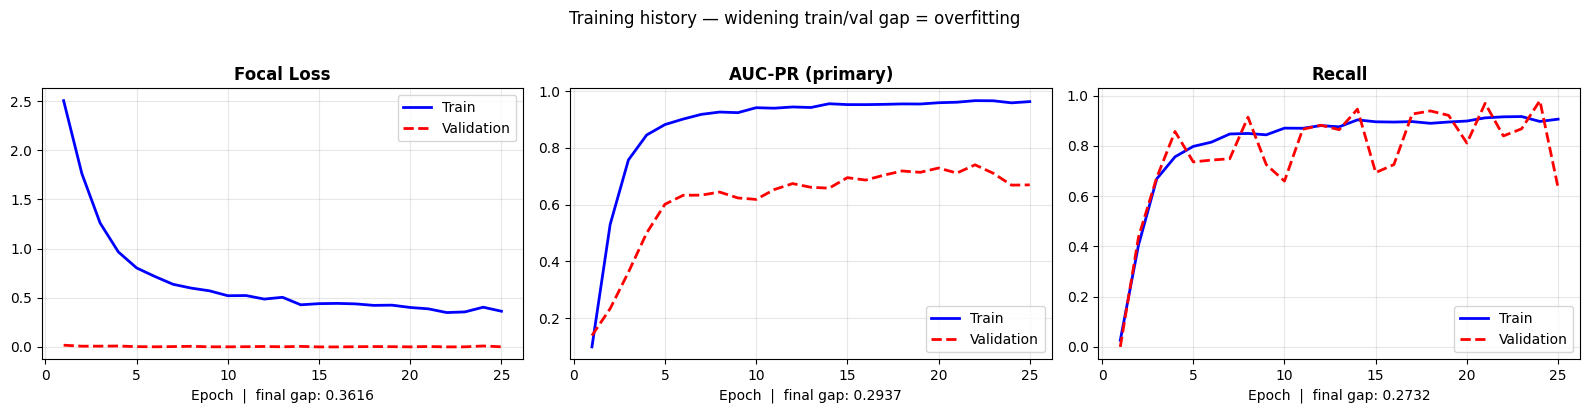

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'auc_pr', 'recall'],
    ['Focal Loss', 'AUC-PR (primary)', 'Recall']
):
    t_vals = history.history[metric]
    v_vals = history.history[f'val_{metric}']
    eps    = range(1, len(t_vals) + 1)
    ax.plot(eps, t_vals, 'b-',  label='Train',      linewidth=2)
    ax.plot(eps, v_vals, 'r--', label='Validation', linewidth=2)
    gap = abs(t_vals[-1] - v_vals[-1])
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Epoch  |  final gap: {gap:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training history — widening train/val gap = overfitting', y=1.02)
plt.tight_layout()
plt.show()

# **3. Model eval**

## 3.1 Evaluation Metrics Explained

For fraud detection, we care about:

**1. Confusion Matrix:**
- True Positives (TP): Correctly identified frauds
- True Negatives (TN): Correctly identified normal
- False Positives (FP): Normal flagged as fraud (false alarms)
- False Negatives (FN): Frauds missed (dangerous!)

**2. Precision = TP / (TP + FP)**
- "Of all fraud predictions, how many were correct?"
- High precision = fewer false alarms

**3. Recall = TP / (TP + FN)**
- "Of all actual frauds, how many did we catch?"
- High recall = catch more frauds

**4. F1-Score**
- Harmonic mean of precision and recall
- Balanced metric when both matter

**5. AUC-ROC**
- Overall ability to distinguish fraud from normal
- 0.5 = random, 1.0 = perfect

## 3.2 eval with default threshold 0.5

In [27]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    """
    Evaluate model and compute all metrics without plotting.
    """

    print("="*60)
    print(f"EVALUATION ON TEST SET (Threshold = {threshold})")
    print("="*60)

    # Get predictions
    print("\nGenerating predictions...")
    y_pred_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("\n" + "-"*60)
    print("CONFUSION MATRIX")
    print("-"*60)
    print(f"\n{'':15} {'Predicted':^20}")
    print(f"{'':15} {'Normal':^10} {'Fraud':^10}")
    print(f"{'Actual Normal':15} {tn:^10,} {fp:^10,}")
    print(f"{'Actual Fraud':15} {fn:^10,} {tp:^10,}")

    # Calculate all metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    # Print metrics
    print("\n" + "-"*60)
    print("METRICS BREAKDOWN")
    print("-"*60)
    print(f"True Positives (TP) - Frauds Caught:  {tp:,}")
    print(f"True Negatives (TN) - Normal Correct: {tn:,}")
    print(f"False Positives (FP) - False Alarms:  {fp:,}")
    print(f"False Negatives (FN) - Frauds Missed: {fn:,}")

    print("\n" + "-"*60)
    print("PERFORMANCE METRICS")
    print("-"*60)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f} (TP / (TP + FP))")
    print(f"Recall:    {recall:.4f} (TP / (TP + FN))")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    print("="*60)

    return y_pred_proba

# Evaluate with default threshold (0.5)
y_pred_proba = evaluate_model(model, X_test, y_test, threshold=0.5)

EVALUATION ON TEST SET (Threshold = 0.5)

Generating predictions...

------------------------------------------------------------
CONFUSION MATRIX
------------------------------------------------------------

                     Predicted      
                  Normal     Fraud   
Actual Normal    947,114     3,248   
Actual Fraud       433       3,575   

------------------------------------------------------------
METRICS BREAKDOWN
------------------------------------------------------------
True Positives (TP) - Frauds Caught:  3,575
True Negatives (TN) - Normal Correct: 947,114
False Positives (FP) - False Alarms:  3,248
False Negatives (FN) - Frauds Missed: 433

------------------------------------------------------------
PERFORMANCE METRICS
------------------------------------------------------------
Accuracy:  0.9961
Precision: 0.5240 (TP / (TP + FP))
Recall:    0.8920 (TP / (TP + FN))
F1-Score:  0.6601
AUC-ROC:   0.9975


## 3.3 Find Optimal Classification Threshold

Instead of using the default 0.5 cutoff, the classification threshold was tuned to better handle class imbalance.  
Lower thresholds increase recall (more fraud detected) while higher thresholds improve precision (fewer false positives).  
The final threshold was selected by maximizing the F1-score to balance precision and recall.


In [28]:
def find_optimal_threshold(y_true, y_pred_proba):
    """
    Find threshold that maximizes F1-score.
    """

    # Get precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)

    # Calculate F1 scores
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

    # Find optimal threshold
    optimal_idx = np.argmax(f1_scores)

    if optimal_idx < len(thresholds):
        optimal_threshold = thresholds[optimal_idx]
    else:
        optimal_threshold = 0.5

    print(f"\nOptimal Threshold: {optimal_threshold:.4f}")
    print(f"Best F1 Score: {f1_scores[optimal_idx]:.4f}")
    print(f"Precision at optimal: {precision[optimal_idx]:.4f}")
    print(f"Recall at optimal: {recall[optimal_idx]:.4f}")
    print("="*60)

    return optimal_threshold

# Find optimal threshold
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)


Optimal Threshold: 0.7752
Best F1 Score: 0.8035
Precision at optimal: 0.8567
Recall at optimal: 0.7565


## 3.4 final eval with optimal threshold

In [29]:
# Evaluate with optimal threshold
_ = evaluate_model(model, X_test, y_test, threshold=optimal_threshold)

EVALUATION ON TEST SET (Threshold = 0.7752100229263306)

Generating predictions...

------------------------------------------------------------
CONFUSION MATRIX
------------------------------------------------------------

                     Predicted      
                  Normal     Fraud   
Actual Normal    949,855      507    
Actual Fraud       976       3,032   

------------------------------------------------------------
METRICS BREAKDOWN
------------------------------------------------------------
True Positives (TP) - Frauds Caught:  3,032
True Negatives (TN) - Normal Correct: 949,855
False Positives (FP) - False Alarms:  507
False Negatives (FN) - Frauds Missed: 976

------------------------------------------------------------
PERFORMANCE METRICS
------------------------------------------------------------
Accuracy:  0.9984
Precision: 0.8567 (TP / (TP + FP))
Recall:    0.7565 (TP / (TP + FN))
F1-Score:  0.8035
AUC-ROC:   0.9975


##SAVING MODEL

In [31]:
import os, pickle
from google.colab import drive, files

drive.mount('/content/drive')
project_folder = '/content/drive/MyDrive/FinGuardAI'
os.makedirs(project_folder, exist_ok=True)

# 1. Save model
model.save(f'{project_folder}/fraud_model.keras')

# 2. Save scaler
with open(f'{project_folder}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save config
config = {
    'optimal_threshold': optimal_threshold,
    'feature_cols'     : feature_cols,
    'SEQ_LEN'          : SEQ_LEN,
    'N_FEATURES'       : N_FEATURES,
}
with open(f'{project_folder}/model_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print('All files saved to Google Drive.')

# Download directly to your computer
files.download(f'{project_folder}/fraud_model.keras')
files.download(f'{project_folder}/scaler.pkl')
files.download(f'{project_folder}/model_config.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>